In [1]:
# ════════════════════════════════════════════════════════════════
# Architecture : CNN 2D sur spectrogramme Mel
# ════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, balanced_accuracy_score,
                              accuracy_score)
from pathlib import Path
WAV_DIR = Path("C:/Users/asalou/S7/stages7/project/wav_audio")
LAB_DIR = Path("C:/Users/asalou/S7/stages7/project/labels")
OUTPUT_DIR = Path("C:/Users/asalou/S7/stages7/project/augmentation")
TARGET_SR  = 16000
SEG_LEN    = 8000

dataset = {}

for file in WAV_DIR.glob("*.wav"):
    y, sr = librosa.load(file, sr=16000)

    dataset[file.stem] = {
        'data': y,
        'filtered': y.copy(),   
        'sr': sr,
        'duration': len(y)/sr,
        'energy': None,
        'times': None,
        'threshold': None,
        'segments': []
    }
print("Dataset chargé :", len(dataset))
# ── Paramètres spectrogramme ──────────────────────────────────
N_MELS   = 64    # nb de bandes Mel  → hauteur de l'image
N_FFT    = 512   # fenêtre FFT
HOP_LEN  = 160   # pas = 10ms → largeur de l'image ≈ 50 frames
# Résultat : image (64, 50) par segment

Dataset chargé : 21


Forme spectrogramme : (64, 51)  (n_mels=64, T=51)


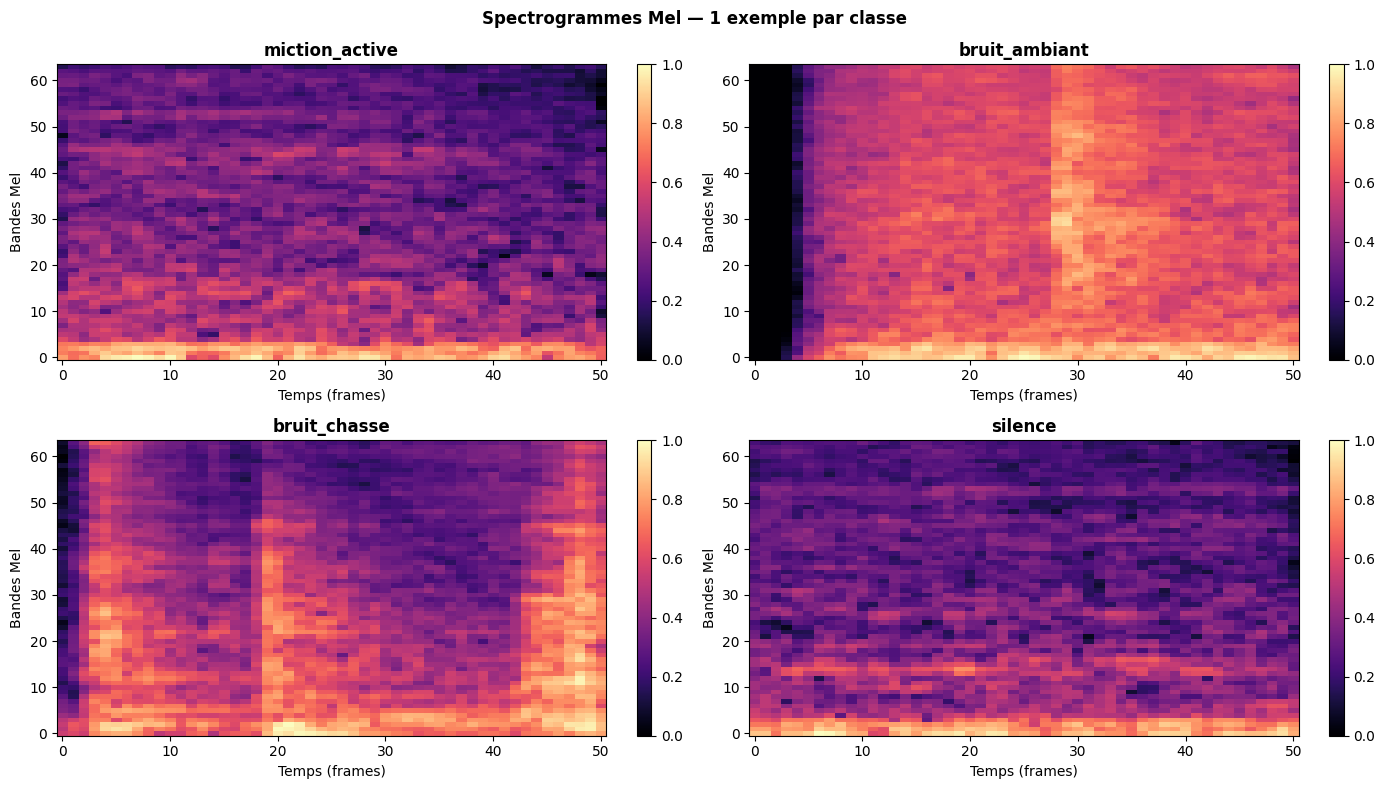

In [2]:
# ════════════════════════════════════════════════════════════════
# CONVERSION SIGNAL → SPECTROGRAMME MEL
# Chaque segment 8000 samples → image (64, 50)
# ════════════════════════════════════════════════════════════════

def signal_to_melspec(segment, sr=TARGET_SR,
                       n_mels=N_MELS, n_fft=N_FFT, hop_len=HOP_LEN):
    """
    Convertit un segment audio en spectrogramme Mel log-normalisé.
    
    Entrée  : signal float32 (8000 samples)
    Sortie  : image (n_mels, T) normalisée [0, 1]
    """
    mel = librosa.feature.melspectrogram(
        y=segment.astype(float), sr=sr,
        n_mels=n_mels, n_fft=n_fft,
        hop_length=hop_len, fmax=6000
    )
    # Conversion en dB
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Normalisation [0, 1]
    mel_min = mel_db.min()
    mel_max = mel_db.max()
    if mel_max - mel_min > 0:
        mel_norm = (mel_db - mel_min) / (mel_max - mel_min)
    else:
        mel_norm = np.zeros_like(mel_db)

    return mel_norm.astype(np.float32)

# ── Test sur un segment ───────────────────────────────────────
X_raw = np.load(f'{OUTPUT_DIR}/X_augmented.npy')
y_raw = np.load(f'{OUTPUT_DIR}/y_augmented.npy')

spec_test = signal_to_melspec(X_raw[0])
print(f"Forme spectrogramme : {spec_test.shape}  "
      f"(n_mels={spec_test.shape[0]}, T={spec_test.shape[1]})")

# ── Visualisation des 4 classes ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Spectrogrammes Mel — 1 exemple par classe', fontweight='bold')

for ax, lbl in zip(axes.flat, ['miction_active','bruit_ambiant',
                                 'bruit_chasse','silence']):
    idx  = np.where(y_raw == lbl)[0][0]
    spec = signal_to_melspec(X_raw[idx])
    im   = ax.imshow(spec, origin='lower', aspect='auto',
                     cmap='magma', vmin=0, vmax=1)
    ax.set_title(lbl, fontweight='bold')
    ax.set_xlabel('Temps (frames)'); ax.set_ylabel('Bandes Mel')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/mel_spectrograms.png', dpi=120, bbox_inches='tight')
plt.show()

In [3]:
# ════════════════════════════════════════════════════════════════
# CONVERSION DATASET COMPLET → SPECTROGRAMMES
# ════════════════════════════════════════════════════════════════

print("Conversion dataset → spectrogrammes Mel...")
print("(3000 segments × (64, 50) = patience ~1min)")

X_mel = np.array([signal_to_melspec(seg) for seg in X_raw],
                  dtype=np.float32)

# Ajouter dimension canal : (N, 64, 50) → (N, 64, 50, 1)
X_mel = X_mel[..., np.newaxis]

print(f" X_mel shape : {X_mel.shape}")
print(f"   Min={X_mel.min():.3f}  Max={X_mel.max():.3f}  "
      f"Moy={X_mel.mean():.3f}")

# ── Encodage labels + split ───────────────────────────────────
le    = LabelEncoder()
y_enc = le.fit_transform(y_raw)
print(f"\nClasses : {le.classes_}")

X_train, X_temp, y_train, y_temp = train_test_split(
    X_mel, y_enc, test_size=0.30, stratify=y_enc, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"\nSplit 70/15/15 :")
print(f"  Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")

# Sauvegarder pour réutilisation
np.save(f'{OUTPUT_DIR}/X_mel.npy', X_mel)
np.save(f'{OUTPUT_DIR}/y_enc.npy', y_enc)
print(f"X_mel.npy sauvegardé")

Conversion dataset → spectrogrammes Mel...
(3000 segments × (64, 50) = patience ~1min)
 X_mel shape : (3000, 64, 51, 1)
   Min=0.000  Max=1.000  Moy=0.426

Classes : ['bruit_ambiant' 'bruit_chasse' 'miction_active' 'silence']

Split 70/15/15 :
  Train : 2100 | Val : 450 | Test : 450
X_mel.npy sauvegardé


In [4]:
# ════════════════════════════════════════════════════════════════
# ARCHITECTURE CNN 2D
#
# Entrée : image (64, 50, 1) — spectrogramme Mel
#
#   Conv2D → détecte des motifs temps-fréquence locaux
#             ex: une bande d'énergie entre 300-3000Hz
#   MaxPool → réduit la résolution, garde les motifs saillants
#   BatchNorm → stabilise l'entraînement
#   GlobalAvgPool → résumé compact de toute l'image
#   Dense + Softmax → classifieur final
# ════════════════════════════════════════════════════════════════

def build_cnn2d(input_shape=(64, 50, 1), n_classes=4):
    inputs = keras.Input(shape=input_shape)

    # ── Bloc 1 : motifs fins (3×3) ────────────────────────────
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # ── Bloc 2 : motifs moyens ────────────────────────────────
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # ── Bloc 3 : motifs larges ────────────────────────────────
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.30)(x)

    # ── Agrégation + classifieur ──────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(64,  activation='relu')(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='CNN2D_MelSpec')

model2d = build_cnn2d(input_shape=X_train.shape[1:])
model2d.summary()
print(f"\nParamètres : {model2d.count_params():,}")

Model: "CNN2D_MelSpec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 64, 51, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 64, 51, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64, 51, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 51, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 51, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 25, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32, 25, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 25, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 25, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 32, 25, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32, 25, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 16, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 16, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 8, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 165,156 (645.14 KB)

 Trainable params: 164,516 (642.64 KB)

 Non-trainable params: 640 (2.50 KB)


Paramètres : 165,156


In [5]:
# ════════════════════════════════════════════════════════════════
# ENTRAÎNEMENT CNN 2D
# ════════════════════════════════════════════════════════════════

model2d.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(
        f'{OUTPUT_DIR}/cnn2d_best_sv.keras',
        monitor='val_accuracy', save_best_only=True, verbose=0),
]

history2d = model2d.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
print(" Entraînement terminé")

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 263ms/step - accuracy: 0.4414 - loss: 1.2792 - val_accuracy: 0.2511 - val_loss: 1.5539 - learning_rate: 0.0010
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 252ms/step - accuracy: 0.6124 - loss: 0.9669 - val_accuracy: 0.2489 - val_loss: 1.8315 - learning_rate: 0.0010
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 253ms/step - accuracy: 0.6852 - loss: 0.8370 - val_accuracy: 0.2511 - val_loss: 2.6058 - learning_rate: 0.0010
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 260ms/step - accuracy: 0.7395 - loss: 0.6914 - val_accuracy: 0.3356 - val_loss: 3.5247 - learning_rate: 0.0010
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 252ms/step - accuracy: 0.7552 - loss: 0.6562 - val_accuracy: 0.2511 - val_loss: 4.6299 - learning_rate: 0.0010
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 253ms/step - accuracy: 0.7748 - loss: 0.6071 - val_accuracy: 0.2711 - val_loss: 4.3844 - learning_rate: 0.0010
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 268ms/step - accuracy: 0.7890 - l

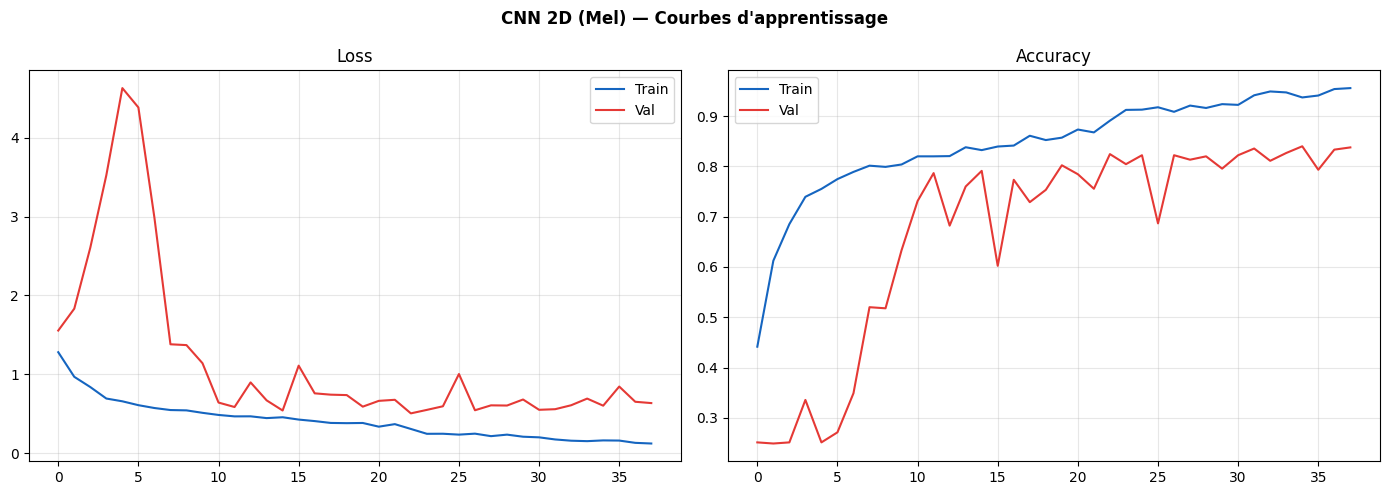

RÉSULTATS CNN 2D (Mel Spectrogram) — Test set
Accuracy          : 0.864
Balanced Accuracy : 0.865

                precision    recall  f1-score   support

 bruit_ambiant      0.811     0.761     0.785       113
  bruit_chasse      0.920     0.929     0.924       112
miction_active      0.962     0.894     0.927       113
       silence      0.778     0.875     0.824       112

      accuracy                          0.864       450
     macro avg      0.868     0.865     0.865       450
  weighted avg      0.868     0.864     0.865       450



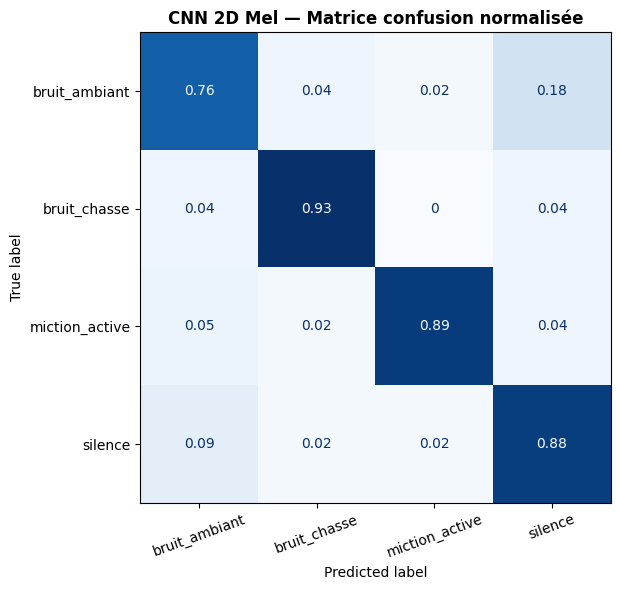


COMPARAISON MODÈLES
Modèle                    |  Accuracy |  Bal.Acc
---------------------------------------------
SVM RBF (baseline)        |     0.766 |    0.777
CNN 2D Mel                |     0.864 |    0.865


In [6]:
# ════════════════════════════════════════════════════════════════
# ÉVALUATION FINALE
# ════════════════════════════════════════════════════════════════

# ── Courbes d'apprentissage ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN 2D (Mel) — Courbes d\'apprentissage', fontweight='bold')

for ax, metric, title in [
    (axes[0], 'loss',     'Loss'),
    (axes[1], 'accuracy', 'Accuracy'),
]:
    ax.plot(history2d.history[metric],          label='Train', color='#1565C0')
    ax.plot(history2d.history[f'val_{metric}'], label='Val',   color='#E53935')
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cnn2d_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Métriques test ────────────────────────────────────────────
y_prob = model2d.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

acc = accuracy_score(y_test, y_pred)
bal = balanced_accuracy_score(y_test, y_pred)

print("="*55)
print("RÉSULTATS CNN 2D (Mel Spectrogram) — Test set")
print("="*55)
print(f"Accuracy          : {acc:.3f}")
print(f"Balanced Accuracy : {bal:.3f}")
print(f"\n{classification_report(y_test, y_pred, target_names=le.classes_, digits=3)}")

# ── Matrice de confusion ──────────────────────────────────────
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=le.classes_).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('CNN 2D Mel — Matrice confusion normalisée', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cnn2d_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Comparaison finale ────────────────────────────────────────
print("\n" + "="*45)
print("COMPARAISON MODÈLES")
print("="*45)
print(f"{'Modèle':25s} | {'Accuracy':>9} | {'Bal.Acc':>8}")
print("-"*45)
print(f"{'SVM RBF (baseline)':25s} | {'0.766':>9} | {'0.777':>8}")
print(f"{'CNN 2D Mel':25s} | {acc:9.3f} | {bal:8.3f}")
print("="*45)

In [8]:
# ════════════════════════════════════════════════════════════════
# CHARGEMENT DES DÉPENDANCES DEPUIS LES AUTRES NOTEBOOKS
# ════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import librosa
import joblib
import json
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder


# ── 2. df_features + feat_load ───────────────────────────────
df_features = pd.read_csv(f'{LAB_DIR}/dataset_features.csv')
feat_load   = joblib.load(f'{LAB_DIR}/feature_cols.pkl')
print(f"✅ df_features : {df_features.shape}")

# ── 3. Modèle CNN 2D ─────────────────────────────────────────
cnn_model = keras.models.load_model(f'{OUTPUT_DIR}/cnn2d_best_sv.keras')
print(f"✅ CNN 2D chargé")

# ── 4. LabelEncoder ──────────────────────────────────────────
y_enc = np.load(f'{OUTPUT_DIR}/y_enc.npy', allow_pickle=True)
y_raw = np.load(f'{OUTPUT_DIR}/y_augmented.npy', allow_pickle=True)
le    = LabelEncoder()
le.fit(y_raw)
print(f"✅ Classes : {le.classes_}")

# ── 5. Fonction spectrogramme ─────────────────────────────────
N_MELS  = 64
N_FFT   = 512
HOP_LEN = 160

def signal_to_melspec(segment, sr=TARGET_SR):
    mel    = librosa.feature.melspectrogram(
        y=segment.astype(float), sr=sr,
        n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_LEN, fmax=6000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mn, mx = mel_db.min(), mel_db.max()
    return ((mel_db - mn) / (mx - mn + 1e-9)).astype(np.float32)

print("✅ Toutes les dépendances chargées")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\asalou\\S7\\stages7\\project\\labels/dataset_features.csv'

In [ ]:
# ════════════════════════════════════════════════════════════════
# VISUALISATION + ÉCOUTE DES PRÉDICTIONS
# ════════════════════════════════════════════════════════════════
from IPython.display import Audio, display
import ipywidgets as widgets

# ── Couleurs par classe ───────────────────────────────────────
COLORS = {
    'miction_active': '#43A047',
    'bruit_ambiant':  '#FF7043',
    'bruit_chasse':   '#00BCD4',
    'silence':        '#90A4AE',
}

def visualiser_predictions(nom_fichier):
    """
    Affiche signal + timeline des prédictions + audio pour un fichier.
    """
    # ── Récupérer le signal ───────────────────────────────────
    filt   = dataset[nom_fichier]['filtered']
    sr     = dataset[nom_fichier]['sr']
    t      = np.linspace(0, len(filt)/sr, len(filt))

    # ── Prédire avec CNN 2D ───────────────────────────────────
    mask   = df_features['fichier'] == nom_fichier
    X_file = df_features[mask][feat_load].values

    # Reconstruire les segments depuis le signal brut
    segments = []
    for i in range(len(X_file)):
        start = i * SEG_LEN
        end   = start + SEG_LEN
        if end > len(filt): break
        segments.append(filt[start:end])

    # Convertir en mel
    X_mel_file = np.array([signal_to_melspec(s) for s in segments])[..., np.newaxis]

    # Prédire
    probas      = cnn_model.predict(X_mel_file, verbose=0)
    y_pred_enc  = np.argmax(probas, axis=1)
    y_pred_lbls = le.inverse_transform(y_pred_enc)
    confiances  = np.max(probas, axis=1)

    n_segs = len(y_pred_lbls)
    t_segs = np.arange(n_segs) * 0.5  # temps en secondes

    # ── Figure ────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(16, 8),
                              gridspec_kw={'height_ratios': [3, 1, 1]})
    fig.suptitle(f'Prédictions CNN 2D — {nom_fichier}',
                 fontweight='bold', fontsize=12)

    # Panneau 1 : signal temporel coloré par prédiction
    axes[0].plot(t, filt, color='#CCCCCC', lw=0.5, alpha=0.8)
    for i, (lbl, conf) in enumerate(zip(y_pred_lbls, confiances)):
        t_start = i * 0.5
        t_end   = t_start + 0.5
        axes[0].axvspan(t_start, t_end,
                        color=COLORS[lbl], alpha=0.35)
    axes[0].set_ylabel('Amplitude')
    axes[0].set_title('Signal temporel (couleurs = labels prédits)')
    axes[0].set_xlim(0, len(filt)/sr)
    axes[0].grid(True, alpha=0.2)

    # Panneau 2 : timeline discrète des labels
    for i, lbl in enumerate(y_pred_lbls):
        axes[1].barh(0, 0.5, left=i*0.5, height=0.8,
                     color=COLORS[lbl], edgecolor='white', linewidth=0.3)
    axes[1].set_xlim(0, n_segs * 0.5)
    axes[1].set_yticks([])
    axes[1].set_title('Timeline des labels prédits')
    axes[1].set_xlabel('Temps (s)')

    # Légende
    import matplotlib.patches as mpatches
    handles = [mpatches.Patch(color=col, label=lbl)
               for lbl, col in COLORS.items()]
    axes[1].legend(handles=handles, loc='upper right',
                   ncol=4, fontsize=8, framealpha=0.9)

    # Panneau 3 : confiance du modèle
    axes[2].bar(t_segs, confiances, width=0.45,
                color=[COLORS[l] for l in y_pred_lbls], alpha=0.8)
    axes[2].axhline(0.60, color='red', ls='--', lw=1.2,
                    label='Seuil confiance 0.60')
    axes[2].set_xlim(0, n_segs * 0.5)
    axes[2].set_ylim(0, 1.05)
    axes[2].set_ylabel('Confiance')
    axes[2].set_title('Confiance par segment (rouge = peu sûr < 0.60)')
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/pred_{nom_fichier}.png',
                dpi=110, bbox_inches='tight')
    plt.show()

    # ── Résumé textuel ────────────────────────────────────────
    from collections import Counter
    counts = Counter(y_pred_lbls)
    print(f"\nRésumé {nom_fichier} :")
    for lbl, n in counts.most_common():
        print(f"  {lbl:20s} : {n:3d} segs ({n*0.5:.1f}s)")
    print(f"  Confiance moyenne  : {confiances.mean():.3f}")
    n_incertains = (confiances < 0.60).sum()
    print(f"  Segments < 0.60    : {n_incertains} ({n_incertains/n_segs*100:.0f}%)")

    # ── Audio complet ─────────────────────────────────────────
    print(f"\n🎧 Écoute complète — {nom_fichier} :")
    display(Audio(filt, rate=sr))

    return y_pred_lbls, confiances


# ── Widget de sélection ───────────────────────────────────────
fichiers = sorted(dataset.keys())

dropdown = widgets.Dropdown(
    options=fichiers,
    value=fichiers[0],
    description='Fichier :',
    layout=widgets.Layout(width='400px')
)

btn = widgets.Button(description='▶ Analyser',
                     button_style='primary',
                     layout=widgets.Layout(width='150px'))

output = widgets.Output()

def on_click(b):
    output.clear_output()
    with output:
        visualiser_predictions(dropdown.value)

btn.on_click(on_click)
display(widgets.HBox([dropdown, btn]))
display(output)

In [ ]:
# ── Charger labels_check depuis le JSON ───────────────────────
with open(f'{OUTPUT_DIR}/labels_segments.json') as f:
    labels_check = json.load(f)

print(f"✅ labels_check chargé : {len(labels_check)} fichiers")
print(f"   Exemple : {list(labels_check.keys())[0]}")

In [ ]:
# ════════════════════════════════════════════════════════════════
# PHASE DE CORRECTION — Contexte local
# Si un segment est différent de ses 2 voisins → corriger
# ════════════════════════════════════════════════════════════════

def corriger_contexte(labels, fenetre=1):
    """
    Corrige un segment isolé incohérent avec son contexte.
    
    Principe :
      Si labels[i-1] == labels[i+1] != labels[i]
      → labels[i] = labels[i-1]  (le segment est une erreur isolée)
    
    fenetre : nb de voisins à considérer de chaque côté (1 ou 2)
    """
    labels = list(labels)
    n      = len(labels)
    corrections = []

    for i in range(fenetre, n - fenetre):
        voisin_gauche = labels[i - fenetre]
        voisin_droite = labels[i + fenetre]

        if voisin_gauche == voisin_droite and labels[i] != voisin_gauche:
            corrections.append({
                'segment':  i,
                'avant':    labels[i],
                'apres':    voisin_gauche,
                't_s':      round(i * 0.5, 2)
            })
            labels[i] = voisin_gauche

    return labels, corrections


# ── Appliquer sur tous les fichiers + mesurer l'impact ────────
from sklearn.metrics import balanced_accuracy_score, accuracy_score

print("Impact de la correction par contexte local")
print("="*65)
print(f"{'Fichier':40s} | {'Corrections':>12} | {'Exemple'}")
print("="*65)

tous_labels_avant  = []
tous_labels_apres  = []
tous_labels_vrais  = []

stats_globales = {'total_corrections': 0, 'par_classe': {}}

for nom_fichier in sorted(dataset.keys()):
    mask   = df_features['fichier'] == nom_fichier
    X_file = df_features[mask][feat_load].values
    if len(X_file) == 0:
        continue

    # Reconstruire segments
    filt     = dataset[nom_fichier]['filtered']
    segments = []
    for i in range(len(X_file)):
        start = i * SEG_LEN
        end   = start + SEG_LEN
        if end > len(filt): break
        segments.append(filt[start:end])

    # Prédire avec CNN
    X_mel_file  = np.array([signal_to_melspec(s) for s in segments])[..., np.newaxis]
    probas      = cnn_model.predict(X_mel_file, verbose=0)
    y_pred_enc  = np.argmax(probas, axis=1)
    labels_pred = list(le.inverse_transform(y_pred_enc))

    # Labels vrais
    labels_vrais = labels_check.get(nom_fichier, [])[:len(labels_pred)]

    # Appliquer correction
    labels_corriges, corrections = corriger_contexte(labels_pred, fenetre=1)

    # Accumuler
    tous_labels_avant.extend(labels_pred)
    tous_labels_apres.extend(labels_corriges)
    tous_labels_vrais.extend(labels_vrais)
    stats_globales['total_corrections'] += len(corrections)

    # Résumé par fichier
    exemple = ""
    if corrections:
        c = corrections[0]
        exemple = f"t={c['t_s']}s : {c['avant']} → {c['apres']}"

    print(f"{nom_fichier:40s} | {len(corrections):>12} | {exemple}")

print("="*65)
print(f"Total corrections : {stats_globales['total_corrections']}")

# ── Mesure de l'impact sur les métriques ─────────────────────
print("\n" + "="*55)
print("IMPACT SUR LES MÉTRIQUES")
print("="*55)

acc_avant  = accuracy_score(tous_labels_vrais, tous_labels_avant)
bal_avant  = balanced_accuracy_score(tous_labels_vrais, tous_labels_avant)
acc_apres  = accuracy_score(tous_labels_vrais, tous_labels_apres)
bal_apres  = balanced_accuracy_score(tous_labels_vrais, tous_labels_apres)

print(f"{'':25s} | {'Accuracy':>9} | {'Bal.Acc':>9}")
print("-"*50)
print(f"{'Avant correction':25s} | {acc_avant:9.3f} | {bal_avant:9.3f}")
print(f"{'Après correction':25s} | {acc_apres:9.3f} | {bal_apres:9.3f}")
print(f"{'Gain':25s} | {acc_apres-acc_avant:+9.3f} | {bal_apres-bal_avant:+9.3f}")
print("="*55)

# ── Détail des corrections par type de transition ─────────────
print("\nTypes de corrections effectuées :")
from collections import Counter
transitions = []
for nom_fichier in sorted(dataset.keys()):
    mask   = df_features['fichier'] == nom_fichier
    X_file = df_features[mask][feat_load].values
    if len(X_file) == 0:
        continue
    filt     = dataset[nom_fichier]['filtered']
    segments = []
    for i in range(len(X_file)):
        start = i * SEG_LEN
        end   = start + SEG_LEN
        if end > len(filt): break
        segments.append(filt[start:end])
    X_mel_file  = np.array([signal_to_melspec(s) for s in segments])[..., np.newaxis]
    probas      = cnn_model.predict(X_mel_file, verbose=0)
    labels_pred = list(le.inverse_transform(np.argmax(probas, axis=1)))
    _, corrections = corriger_contexte(labels_pred, fenetre=1)
    for c in corrections:
        transitions.append(f"{c['avant']} → {c['apres']}")

for trans, count in Counter(transitions).most_common():
    print(f"  {trans:40s} : {count:4d} fois")

In [ ]:
# ── Tester différentes fenêtres de correction ─────────────────
print("Impact selon la fenêtre de correction")
print("="*55)
print(f"{'Fenêtre':15s} | {'Corrections':>12} | {'Accuracy':>9} | {'Bal.Acc':>9}")
print("="*55)

for fenetre in [1, 2, 3]:
    labels_av, labels_ap, labels_vr = [], [], []
    n_corr = 0

    for nom_fichier in sorted(dataset.keys()):
        mask   = df_features['fichier'] == nom_fichier
        X_file = df_features[mask][feat_load].values
        if len(X_file) == 0:
            continue
        filt     = dataset[nom_fichier]['filtered']
        segments = []
        for i in range(len(X_file)):
            start = i * SEG_LEN
            end   = start + SEG_LEN
            if end > len(filt): break
            segments.append(filt[start:end])

        X_mel_file  = np.array([signal_to_melspec(s) for s in segments])[..., np.newaxis]
        probas      = cnn_model.predict(X_mel_file, verbose=0)
        labels_pred = list(le.inverse_transform(np.argmax(probas, axis=1)))
        labels_vrais = labels_check.get(nom_fichier, [])[:len(labels_pred)]

        labels_corriges, corrections = corriger_contexte(labels_pred, fenetre=fenetre)
        labels_av.extend(labels_pred)
        labels_ap.extend(labels_corriges)
        labels_vr.extend(labels_vrais)
        n_corr += len(corrections)

    acc = accuracy_score(labels_vr, labels_ap)
    bal = balanced_accuracy_score(labels_vr, labels_ap)
    print(f"{'fenetre='+str(fenetre):15s} | {n_corr:>12} | {acc:9.3f} | {bal:9.3f}")

print("="*55)

# ── Tester correction uniquement sur classes ciblées ──────────
# Corriger seulement silence ↔ bruit_ambiant (la confusion principale)
def corriger_contexte_cible(labels, fenetre=1,
                             paires=[('silence','bruit_ambiant'),
                                     ('bruit_ambiant','silence')]):
    """
    Correction ciblée — uniquement les confusions connues.
    """
    labels = list(labels)
    n      = len(labels)
    corrections = []

    for i in range(fenetre, n - fenetre):
        vg = labels[i - fenetre]
        vd = labels[i + fenetre]
        if vg == vd and labels[i] != vg:
            # Vérifier que c'est une confusion connue
            if (labels[i], vg) in paires or (vg, labels[i]) in paires:
                corrections.append({'segment':i,'avant':labels[i],'apres':vg})
                labels[i] = vg

    return labels, corrections

# Évaluer correction ciblée
labels_av2, labels_ap2, labels_vr2 = [], [], []
for nom_fichier in sorted(dataset.keys()):
    mask   = df_features['fichier'] == nom_fichier
    X_file = df_features[mask][feat_load].values
    if len(X_file) == 0:
        continue
    filt     = dataset[nom_fichier]['filtered']
    segments = []
    for i in range(len(X_file)):
        start = i * SEG_LEN
        end   = start + SEG_LEN
        if end > len(filt): break
        segments.append(filt[start:end])
    X_mel_file  = np.array([signal_to_melspec(s) for s in segments])[..., np.newaxis]
    probas      = cnn_model.predict(X_mel_file, verbose=0)
    labels_pred = list(le.inverse_transform(np.argmax(probas, axis=1)))
    labels_vrais = labels_check.get(nom_fichier, [])[:len(labels_pred)]
    labels_corriges, _ = corriger_contexte_cible(labels_pred, fenetre=1)
    labels_av2.extend(labels_pred)
    labels_ap2.extend(labels_corriges)
    labels_vr2.extend(labels_vrais)

acc2 = accuracy_score(labels_vr2, labels_ap2)
bal2 = balanced_accuracy_score(labels_vr2, labels_ap2)
print(f"\nCorrection ciblée (silence↔bruit_ambiant uniquement) :")
print(f"  Accuracy  : {acc2:.3f}")
print(f"  Bal.Acc   : {bal2:.3f}")